# SVM metadata model

Binary classification using patient metadata.

Current hypothesis:
- H1: biopsy recommendation
- H2: malignancy among biopsied lesions

Model selection is performed exclusively on the training set using patient-grouped cross-validation.

Predictor standardization is included in the SVM pipeline to ensure that variables measured on different scales contribute appropriately to the model.

## 1. Imports and configuration 

In [10]:
# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------


import numpy as np
import pandas as pd

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedGroupKFold,
)

from sklearn.metrics import (
    auc,
    make_scorer,
    precision_recall_curve,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from skin_lesion_ai.inference.evaluation import (
    evaluate,
    save_model,
)
from skin_lesion_ai.utils.data_utils import load_metadata_parquet


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

HYPOTHESIS = 2

RANDOM_STATE = 42
N_CV_SPLITS = 5

HYPOTHESIS_CONFIG = {
    1: {
        "target": "target_biopsy",
        "split_suffix": "h1",
        "description": "Biopsy recommendation",
    },
    2: {
        "target": "target_malignant",
        "split_suffix": "h2",
        "description": "Malignancy among biopsied lesions",
    },
}

if HYPOTHESIS not in HYPOTHESIS_CONFIG:
    raise ValueError("HYPOTHESIS must be either 1 or 2.")

TARGET = HYPOTHESIS_CONFIG[HYPOTHESIS]["target"]
SPLIT_SUFFIX = HYPOTHESIS_CONFIG[HYPOTHESIS]["split_suffix"]
HYPOTHESIS_DESCRIPTION = HYPOTHESIS_CONFIG[HYPOTHESIS]["description"]

MODEL_NAME = f"svm_metadata_h{HYPOTHESIS}"

print(f"Hypothesis {HYPOTHESIS}: {HYPOTHESIS_DESCRIPTION}")
print(f"Target: {TARGET}")
print(f"Model name: {MODEL_NAME}")

Hypothesis 2: Malignancy among biopsied lesions
Target: target_malignant
Model name: svm_metadata_h2


## 2. Load train, validation and test splits 

In [11]:
df_train = load_metadata_parquet(
    stage="processed",
    filename=f"train_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)

df_validation = load_metadata_parquet(
    stage="processed",
    filename=f"val_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)

df_test = load_metadata_parquet(
    stage="processed",
    filename=f"test_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)


split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "lesions": [
            len(df_train),
            len(df_validation),
            len(df_test),
        ],
        "patients": [
            df_train["patient_id"].nunique(),
            df_validation["patient_id"].nunique(),
            df_test["patient_id"].nunique(),
        ],
        "positive_rate": [
            df_train[TARGET].mean(),
            df_validation[TARGET].mean(),
            df_test[TARGET].mean(),
        ],
    }
)

display(split_summary)

,split,lesions,patients,positive_rate
0,train,811,504,0.374846
1,validation,101,64,0.376238
2,test,101,61,0.376238


## 3. Define predictors and target

The model uses four clinical metadata predictors:

- sex
- age
- anatomical site
- lesion diameter

Categorical variables use the encodings generated during preprocessing.
Anatomical site is represented through one-hot encoded columns rather than the integer code, avoiding the introduction of an artificial ordinal relationship.

These variables result in eight columns used as predictors by the model.

In [12]:
FEATURES = [
    "sex_male",
    "age_approx",
    "anatom_site__anterior_torso",
    "anatom_site__head_neck",
    "anatom_site__lower_extremity",
    "anatom_site__posterior_torso",
    "anatom_site__upper_extremity",
    "clin_size_long_diam_mm",
]

ID_COLUMN = "isic_id"
GROUP_COLUMN = "patient_id"


required_columns = {
    ID_COLUMN,
    GROUP_COLUMN,
    TARGET,
    *FEATURES,
}

for split_name, df_split in {
    "train": df_train,
    "validation": df_validation,
    "test": df_test,
}.items():
    missing_columns = required_columns.difference(df_split.columns)

    if missing_columns:
        raise KeyError(
            f"{split_name} is missing required columns: {sorted(missing_columns)}"
        )

    if df_split[FEATURES].isna().any().any():
        raise ValueError(f"Missing predictor values found in {split_name}.")

print(f"Number of model columns: {len(FEATURES)}")
print("Predictors:")
for feature in FEATURES:
    print(f"- {feature}")

Number of model columns: 8
Predictors:
- sex_male
- age_approx
- anatom_site__anterior_torso
- anatom_site__head_neck
- anatom_site__lower_extremity
- anatom_site__posterior_torso
- anatom_site__upper_extremity
- clin_size_long_diam_mm


## 4. Prepare modelling matrices

Predictor matrices and target vectors are created for each split.

Patient identifiers are additionally retained as grouping labels for the cross-validation procedure. It is not used as a predictor. This allows `StratifiedGroupKFold` to preserve patient independence within the training set and prevents lesions from the same patient from appearing in both training and validation folds, that is to say, it uses this information to keep all lesions from the same patient within the same fold.

In [13]:
# Training data
X_train = df_train[FEATURES].copy()
y_train = df_train[TARGET].astype(int).copy()
groups_train = df_train[GROUP_COLUMN].copy()

# Validation data
X_validation = df_validation[FEATURES].copy()
y_validation = df_validation[TARGET].astype(int).copy()

# Test data
X_test = df_test[FEATURES].copy()
y_test = df_test[TARGET].astype(int).copy()


print("Training:")
print(f"  X: {X_train.shape}")
print(f"  y: {y_train.shape}")
print(f"  patients: {groups_train.nunique():,}")

print("\nValidation:")
print(f"  X: {X_validation.shape}")
print(f"  y: {y_validation.shape}")

print("\nTest:")
print(f"  X: {X_test.shape}")
print(f"  y: {y_test.shape}")

Training:
  X: (811, 8)
  y: (811,)
  patients: 504

Validation:
  X: (101, 8)
  y: (101,)

Test:
  X: (101, 8)
  y: (101,)


## 5. Cross-validation and scoring strategy

Hyperparameter optimization is performed exclusively within the training set.

Because multiple lesions may belong to the same patient, standard stratified cross-validation would introduce patient-level leakage between folds.
Therefore, a `StratifiedGroupKFold` strategy is used, preserving class balance as far as possible while ensuring that all lesions from the same patient remain within the same fold.

The same five folds are precomputed and reused throughout all hyperparameter search stages to ensure a fair comparison between candidate models.

Candidate models are evaluated using three threshold-independent metrics:

1. **PR-AUC**, used as the primary selection criterion because of the strong class imbalance.
2. **ROC-AUC**, used as the first tie-breaker.
3. **Brier score**, used as the second tie-breaker to favor better-calibrated probability estimates.

PR-AUC is computed as the trapezoidal area under the Precision-Recall curve, using the same definition as the final evaluation pipeline.

No classification threshold is selected during cross-validation. Clinical threshold selection is performed later and exclusively on the validation set.

In [14]:
# ---------------------------------------------------------------------
# Cross-validation
# ---------------------------------------------------------------------

cv = StratifiedGroupKFold(
    n_splits=N_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Precompute folds so that exactly the same splits are reused during all hyperparameter search stages.
cv_splits = list(
    cv.split(
        X=X_train,
        y=y_train,
        groups=groups_train,
    )
)


# ---------------------------------------------------------------------
# Validate CV folds
# ---------------------------------------------------------------------

cv_summary = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    train_patients = set(groups_train.iloc[train_idx])
    val_patients = set(groups_train.iloc[val_idx])

    if train_patients.intersection(val_patients):
        raise ValueError(f"Patient leakage detected in CV fold {fold}.")

    cv_summary.append(
        {
            "fold": fold,
            "train_lesions": len(train_idx),
            "validation_lesions": len(val_idx),
            "train_patients": len(train_patients),
            "validation_patients": len(val_patients),
            "train_positive_rate": y_train.iloc[train_idx].mean(),
            "validation_positive_rate": y_train.iloc[val_idx].mean(),
        }
    )

cv_summary = pd.DataFrame(cv_summary)

display(cv_summary)

,fold,train_lesions,validation_lesions,train_patients,validation_patients,train_positive_rate,validation_positive_rate
0,1,649,162,400,104,0.374422,0.376543
1,2,649,162,401,103,0.374422,0.376543
2,3,649,162,402,102,0.375963,0.370370
3,4,649,162,409,95,0.374422,0.376543
4,5,648,163,404,100,0.375000,0.374233


In [15]:
# ---------------------------------------------------------------------
# Scoring functions
# ---------------------------------------------------------------------


def trapezoidal_pr_auc(y_true, y_prob):
    """Compute trapezoidal area under the Precision-Recall curve."""
    precision, recall, _ = precision_recall_curve(
        y_true,
        y_prob,
    )

    return auc(recall, precision)


pr_auc_scorer = make_scorer(
    trapezoidal_pr_auc,
    response_method="predict_proba",
)


SCORING = {
    "pr_auc": pr_auc_scorer,
    "roc_auc": "roc_auc",
    "brier": "neg_brier_score",
}


def select_best_candidate(cv_results):
    """Select the best candidate using PR-AUC > ROC-AUC > Brier score."""

    results = pd.DataFrame(cv_results)

    ranked_results = results.sort_values(
        by=[
            "mean_test_pr_auc",
            "mean_test_roc_auc",
            "mean_test_brier",
        ],
        ascending=[
            False,
            False,
            False,
        ],
        na_position="last",
    )

    return int(ranked_results.index[0])

## 6. Broad hyperparameter search

A broad randomized search is first performed to explore the main SVM hyperparameters.

The search evaluates the two kernels (determines the type of decision boundary) considered in this experiment:

- `linear`, which produces a linear decision boundary.
- `rbf`, which allows a non-linear decision boundary.

The main hyperparameters explored are:

- `C`, which controls the trade-off between a wider margin and classification errors;
- `gamma`, which controls the influence of individual observations when the RBF kernel is used;
- and different strategies for handling class imbalance through `class_weight`.

Parameters related mainly to the execution of the algorithm, such as `cache_size`, `max_iter` and `tol`, are fixed rather than optimized because they control computational behaviour and convergence rather than the model complexity.

The SVM predictors are standardized inside a `Pipeline` before model fitting. This prevents the scaling parameters from being estimated using validation folds during cross-validation.

Probability estimation is enabled because the evaluation pipeline requires positive-class probabilities for PR-AUC, Brier score and threshold selection.

A randomized search is used in this stage to explore the parameter space before performing a smaller exhaustive search around the best configuration.

In [16]:
# ---------------------------------------------------------------------
# Class imbalance
# ---------------------------------------------------------------------

n_negative = int((y_train == 0).sum())
n_positive = int((y_train == 1).sum())

class_ratio = n_negative / n_positive

class_weight_values = [
    None,
    "balanced",
    {0: 1, 1: round(np.sqrt(class_ratio), 4)},
    {0: 1, 1: round(class_ratio, 4)},
]

print(f"Negative lesions: {n_negative:,}")
print(f"Positive lesions: {n_positive:,}")
print(f"Negative / positive ratio: {class_ratio:.3f}")
print("class_weight candidates:")

for value in class_weight_values: 
    print(f"- {value}")

Negative lesions: 507
Positive lesions: 304
Negative / positive ratio: 1.668
class_weight candidates:
- None
- balanced
- {0: 1, 1: 1.2914}
- {0: 1, 1: 1.6678}


### Class imbalance

The training data presents a strong class imbalance. Therefore, different class-weighting strategies are included in the hyperparameter search.

- `None`, with equal weight for both classes;
- `"balanced"`, which automatically assigns weights inversely proportional to class frequencies;
- an intermediate positive-class weight based on the square root of the negative-to-positive ratio;
- the full negative-to-positive ratio.

The purpose is to allow cross-validation to determine whether and how much class weighting improves the model's ability to identify the minority class.

### SVM pipeline

SVM is sensitive to the scale of the predictors, especially when using the RBF kernel. For this reason, the predictors are standardized before training.

The `StandardScaler` is included inside a `Pipeline` with the SVM model. This ensures that the scaling parameters are calculated independently within each training fold during cross-validation and avoids data leakage.

The same pipeline is used during hyperparameter optimization and final model fitting.

In [17]:
# ---------------------------------------------------------------------
# Base SVM classifier
# ---------------------------------------------------------------------

svm_model = Pipeline(
    [("scaler", StandardScaler()),
     ("svm", SVC(probability=True,
                 random_state=RANDOM_STATE,
                 cache_size=1024,
                 max_iter=-1,
                 tol=1e-3)),
    ]
)


# ---------------------------------------------------------------------
# Broad search space
# ---------------------------------------------------------------------

broad_param_space = [
    {
        "svm__kernel": ["linear"],
        "svm__C": np.logspace(-3, 3, 13),
        "svm__class_weight": class_weight_values,
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": np.logspace(-3, 3, 13),
        "svm__gamma": ["scale", "auto"] + list(np.logspace(-4, 1, 10)),
        "svm__class_weight": class_weight_values,
    },
]

In [18]:
# ---------------------------------------------------------------------
# Broad randomized search
# ---------------------------------------------------------------------

N_RANDOM_ITER = 20

broad_search = RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=broad_param_space,
    n_iter=N_RANDOM_ITER,
    scoring=SCORING,
    refit=select_best_candidate,
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=2, # test with -1 y 2  
    pre_dispatch="n_jobs",
    verbose=2,
    return_train_score=False,
    error_score="raise",
)

broad_search.fit(
    X_train,
    y_train,
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


d:\Workspace\research\ub_master_thesis\my-image-classifier\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'svm__C': array([1.0000...00000000e+03]), 'svm__class_weight': [None, 'balanced', ...], 'svm__kernel': ['linear']}, {'svm__C': array([1.0000...00000000e+03]), 'svm__class_weight': [None, 'balanced', ...], 'svm__gamma': ['scale', 'auto', ...], 'svm__kernel': ['rbf']}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'brier': 'neg_brier_score', 'pr_auc': make_scorer(t...redict_proba'), 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function sel...0025D09199C60>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For intege

In [19]:
# ---------------------------------------------------------------------
# Top broad-search candidates: show the best kernel and estimator
# ---------------------------------------------------------------------

broad_results = pd.DataFrame(broad_search.cv_results_)

display(
    broad_results[
        [
            "param_svm__kernel",
            "mean_test_pr_auc",
            "mean_test_roc_auc",
            "mean_test_brier",
            "mean_fit_time",
        ]
    ].sort_values(
        by=[
            "mean_test_pr_auc",
            "mean_test_roc_auc",
            "mean_test_brier",
        ],
        ascending=[
            False,
            False,
            False,
        ],
        na_position="last",
    ).head(10)
)

,param_svm__kernel,mean_test_pr_auc,mean_test_roc_auc,mean_test_brier,mean_fit_time
2,rbf,0.636159,0.748518,-0.196704,0.092106
5,rbf,0.631328,0.746261,-0.223908,0.060951
10,rbf,0.629802,0.745475,-0.222427,0.077523
17,rbf,0.624866,0.743876,-0.210283,0.083782
7,rbf,0.623995,0.741323,-0.197827,0.098190
13,rbf,0.621234,0.741756,-0.203783,0.090788
9,rbf,0.619805,0.741327,-0.198449,0.077101
16,rbf,0.610278,0.735980,-0.199631,0.089574
6,rbf,0.606419,0.735544,-0.199628,0.131315
15,rbf,0.583885,0.706879,-0.209104,0.094152


## 7. Refined hyperparameter search

The best configuration from the broad randomized search is used to define a smaller local search space.

The refined search focuses on the main SVM parameters controlling the decision boundary:

- `C`;
- `kernel`;
- `gamma` for the RBF kernel;
- `class_weight`.

The kernel selected during the broad search is retained for the refined stage. Parameters related to the computational configuration of the SVM are kept fixed.

The broad-search optimum is explicitly included in the refined grid.

In [20]:
# ---------------------------------------------------------------------
# Best broad-search configuration
# ---------------------------------------------------------------------

broad_best_params = broad_search.best_params_

broad_results = pd.DataFrame(broad_search.cv_results_)
broad_best_row = broad_results.loc[broad_search.best_index_]

print("Broad search best CV performance:")
print(
    f"PR-AUC: "
    f"{broad_best_row['mean_test_pr_auc']:.5f} "
    f"± {broad_best_row['std_test_pr_auc']:.5f}"
)
print(
    f"ROC-AUC: "
    f"{broad_best_row['mean_test_roc_auc']:.5f} "
    f"± {broad_best_row['std_test_roc_auc']:.5f}"
)
print(f"Brier score: {-broad_best_row['mean_test_brier']:.5f}")

print("\nBest broad-search parameters:")
display(broad_best_params)

Broad search best CV performance:
PR-AUC: 0.63616 ± 0.07513
ROC-AUC: 0.74852 ± 0.05240
Brier score: 0.19670

Best broad-search parameters:


{'svm__kernel': 'rbf',
 'svm__gamma': 0.004641588833612782,
 'svm__class_weight': {0: 1, 1: 1.2914},
 'svm__C': 1.0}

In [21]:
# ---------------------------------------------------------------------
# Build refined grid around broad-search optimum
# ---------------------------------------------------------------------

best_C = broad_best_params["svm__C"]
best_kernel = broad_best_params["svm__kernel"]
# best_class_weight = broad_best_params["svm__class_weight"]
if best_kernel == "rbf":
    best_gamma = broad_best_params["svm__gamma"]

if best_kernel == "linear":

    refined_param_grid = {
        "svm__kernel": ["linear"],
        "svm__C": sorted(
            {
                max(0.001, best_C / 3),
                best_C,
                best_C * 3,
            }
        ),
        "svm__class_weight": class_weight_values, # it could be best_class_weight 
    }

# if best_kernel == "rbf":
else:

    gamma_values = (
        ["scale", "auto"]
        if best_gamma in ["scale", "auto"]
        else [
            best_gamma / 3,
            best_gamma,
            best_gamma * 3,
        ]
    )

    refined_param_grid = {
        "svm__kernel": ["rbf"],
        "svm__C": sorted(
            {
                max(0.001, best_C / 3),
                best_C,
                best_C * 3,
            }
        ),
        "svm__gamma": gamma_values,
        "svm__class_weight": class_weight_values, # it could be best_class_weight 
    }

refined_param_grid

{'svm__kernel': ['rbf'],
 'svm__C': [0.3333333333333333, 1.0, 3.0],
 'svm__gamma': [0.0015471962778709275,
  0.004641588833612782,
  0.013924766500838348],
 'svm__class_weight': [None, 'balanced', {0: 1, 1: 1.2914}, {0: 1, 1: 1.6678}]}

In [22]:
# ---------------------------------------------------------------------
# Fix broad-search sampling and regularization parameters
# ---------------------------------------------------------------------

refined_svm_model = Pipeline(
    [("scaler", StandardScaler()),
     ("svm", SVC(probability=True,
                 random_state=RANDOM_STATE,
                 cache_size=1024,
                 max_iter=-1,
                 tol=1e-3
                # there are no sampling and regularization parameters to fix for SVM
                 )),
    ]
)

In [23]:
# ---------------------------------------------------------------------
# Refined exhaustive search
# ---------------------------------------------------------------------

refined_search = GridSearchCV(
    estimator=refined_svm_model,
    param_grid=refined_param_grid,
    scoring=SCORING,
    refit=select_best_candidate,
    cv=cv_splits,
    n_jobs=2, # test with -1 y 2  
    pre_dispatch="n_jobs",
    verbose=2,
    return_train_score=False,
    error_score="raise",
)

refined_search.fit(
    X_train,
    y_train,
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


d:\Workspace\research\ub_master_thesis\my-image-classifier\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.3333333333333333, 1.0, ...], 'svm__class_weight': [None, 'balanced', ...], 'svm__gamma': [0.0015471962778709275, 0.004641588833612782, ...], 'svm__kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'brier': 'neg_brier_score', 'pr_auc': make_scorer(t...redict_proba'), 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",<function sel...0025D09199C60>
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_vali

## 8. Cross-validation results and final model

The best configurations from the broad and refined searches are compared using their mean cross-validated PR-AUC, ROC-AUC and Brier score.

The final configuration is selected using the predefined hierarchy:

**PR-AUC → ROC-AUC → Brier score.**

Because the refined `GridSearchCV` uses `refit`, the selected estimator is automatically retrained on the complete training set after hyperparameter selection. No additional manual fitting step is therefore required.

In [24]:
# ---------------------------------------------------------------------
# Collect CV results
# ---------------------------------------------------------------------

broad_cv_results = pd.DataFrame(broad_search.cv_results_)

refined_cv_results = pd.DataFrame(refined_search.cv_results_)


def get_best_search_result(search, search_name):
    """Return the selected CV result from one search stage."""

    results = pd.DataFrame(search.cv_results_)
    row = results.loc[search.best_index_]

    return {
        "search": search_name,
        "pr_auc": row["mean_test_pr_auc"],
        "pr_auc_std": row["std_test_pr_auc"],
        "roc_auc": row["mean_test_roc_auc"],
        "roc_auc_std": row["std_test_roc_auc"],
        "brier_score": -row["mean_test_brier"],
        "brier_score_std": row["std_test_brier"],
    }


search_comparison = pd.DataFrame(
    [
        get_best_search_result(
            broad_search,
            "Broad randomized search",
        ),
        get_best_search_result(
            refined_search,
            "Refined grid search",
        ),
    ]
)

display(search_comparison)

,search,pr_auc,pr_auc_std,roc_auc,roc_auc_std,brier_score,brier_score_std
0,Broad randomized search,0.636159,0.075132,0.748518,0.052404,0.196704,0.015982
1,Refined grid search,0.650790,0.081979,0.753876,0.056066,0.194581,0.018357


In [25]:
# ---------------------------------------------------------------------
# Top refined-search candidates
# ---------------------------------------------------------------------

top_refined_models = refined_cv_results.copy()

top_refined_models["mean_brier_score"] = -top_refined_models["mean_test_brier"]

top_refined_models = (
    top_refined_models.sort_values(
        by=[
            "mean_test_pr_auc",
            "mean_test_roc_auc",
            "mean_test_brier",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )[
        [
            "params",
            "mean_test_pr_auc",
            "std_test_pr_auc",
            "mean_test_roc_auc",
            "std_test_roc_auc",
            "mean_brier_score",
            "std_test_brier",
            "mean_fit_time",
        ]
    ]
    .head(10)
    .reset_index(drop=True)
)

display(top_refined_models)

,params,mean_test_pr_auc,std_test_pr_auc,mean_test_roc_auc,std_test_roc_auc,mean_brier_score,std_test_brier,mean_fit_time
0,"{'svm__C': 0.3333333333333333, 'svm__class_wei...",0.650790,0.081979,0.753876,0.056066,0.194581,0.018357,0.098962
1,"{'svm__C': 0.3333333333333333, 'svm__class_wei...",0.649465,0.080332,0.752740,0.055337,0.194707,0.018444,0.106232
2,"{'svm__C': 1.0, 'svm__class_weight': 'balanced...",0.644401,0.088072,0.750888,0.058296,0.195508,0.019084,0.095369
3,"{'svm__C': 3.0, 'svm__class_weight': {0: 1, 1:...",0.644191,0.078464,0.751002,0.052785,0.194691,0.017061,0.119453
4,"{'svm__C': 1.0, 'svm__class_weight': {0: 1, 1:...",0.644030,0.089773,0.749729,0.058737,0.195698,0.019271,0.097239
5,"{'svm__C': 3.0, 'svm__class_weight': 'balanced...",0.643884,0.090228,0.749853,0.059009,0.195840,0.019373,0.084710
6,"{'svm__C': 3.0, 'svm__class_weight': {0: 1, 1:...",0.642716,0.090179,0.748792,0.059041,0.195843,0.019454,0.108578
7,"{'svm__C': 1.0, 'svm__class_weight': {0: 1, 1:...",0.640478,0.079652,0.745832,0.057179,0.197514,0.018217,0.117268
8,"{'svm__C': 0.3333333333333333, 'svm__class_wei...",0.640243,0.079768,0.746383,0.056557,0.197280,0.017900,0.110213
9,"{'svm__C': 1.0, 'svm__class_weight': 'balanced...",0.639134,0.080851,0.745244,0.057493,0.198056,0.017790,0.095743


In [26]:
# ---------------------------------------------------------------------
# Final model: 
# For reproducibility, we will use the best model from the refined search, 
# which has been automatically refitted on the entire training set.
# ---------------------------------------------------------------------

best_model = refined_search.best_estimator_

final_model_params = {
    **broad_best_params,
    **refined_search.best_params_,
}

print("Final selected hyperparameters:")
display(final_model_params)

print(f"Final model automatically refitted on {len(X_train):,} training lesions.")

Final selected hyperparameters:


{'svm__kernel': 'rbf',
 'svm__gamma': 0.013924766500838348,
 'svm__class_weight': {0: 1, 1: 1.6678},
 'svm__C': 0.3333333333333333}

Final model automatically refitted on 811 training lesions.


In [27]:
# ---------------------------------------------------------------------
# Final model parameters: Just for the SVM parameters
# ---------------------------------------------------------------------

final_svm_params = best_model.named_steps["svm"].get_params()

final_model_params = {
    key: final_svm_params[key]
    for key in [
        "C",
        "kernel",
        "gamma",
        "class_weight",
        "probability",
        "cache_size",
        "max_iter",
        "tol",
    ]
}

print("Final selected SVM parameters:")
display(final_model_params)

print(
    f"Final model automatically refitted on "
    f"{len(X_train):,} training lesions."
)

Final selected SVM parameters:


{'C': 0.3333333333333333,
 'kernel': 'rbf',
 'gamma': 0.013924766500838348,
 'class_weight': {0: 1, 1: 1.6678},
 'probability': True,
 'cache_size': 1024,
 'max_iter': -1,
 'tol': 0.001}

Final model automatically refitted on 811 training lesions.


## 9. Save final model

The best SVM pipeline selected through cross-validation is saved before evaluating its performance on the validation set.

The complete pipeline is saved, including the `StandardScaler` and the SVM classifier, so that the same preprocessing and model configuration can be reused for future predictions without additional fitting.

In [28]:
# ---------------------------------------------------------------------
# Save final model
# ---------------------------------------------------------------------

model_directory = save_model(
    model=best_model,
    model_name=MODEL_NAME,
    model_type=1,
)

print(f"Model directory: {model_directory}")

Model saved in: D:\Workspace\research\ub_master_thesis\my-image-classifier\data\models\svm_metadata_h2\model.joblib
Model directory: D:\Workspace\research\ub_master_thesis\my-image-classifier\data\models\svm_metadata_h2


## 10. Generate prediction probabilities

Positive-class probabilities are generated for the training and validation sets using the selected SVM pipeline.

The pipeline applies the previously fitted standardization before generating the SVM probability estimates. The resulting probabilities are stored together with the lesion identifiers and are used as input for the evaluation pipeline.

In [29]:
# ---------------------------------------------------------------------
# Generate prediction probabilities
# ---------------------------------------------------------------------

train_probabilities = best_model.predict_proba(X_train)[:, 1]

validation_probabilities = best_model.predict_proba(X_validation)[:, 1]


df_train_predictions = pd.DataFrame(
    {
        "isic_id": df_train["isic_id"].to_numpy(),
        "probability": train_probabilities,
    }
)

df_validation_predictions = pd.DataFrame(
    {
        "isic_id": df_validation["isic_id"].to_numpy(),
        "probability": validation_probabilities,
    }
)

display(df_train_predictions.head())
display(df_validation_predictions.head())

,isic_id,probability
0,ISIC_0077462,0.671793
1,ISIC_0079802,0.115351
2,ISIC_0082829,0.631129
3,ISIC_0085805,0.144566
4,ISIC_0096034,0.813197


,isic_id,probability
0,ISIC_0293670,0.368523
1,ISIC_0373748,0.339635
2,ISIC_0470650,0.140121
3,ISIC_0664135,0.672990
4,ISIC_0699524,0.385713


## 11. Train and validation evaluation

Threshold-independent discrimination and calibration metrics are calculated for both the training and validation sets. The clinical classification threshold is selected exclusively from the validation set by maximizing specificity while maintaining the predefined minimum sensitivity.

The selected threshold is subsequently applied unchanged to both training and validation data.

The evaluation is performed using the positive-class probabilities generated by the selected SVM pipeline.

In [30]:
# ---------------------------------------------------------------------
# Evaluate final model: Train and validation evaluation   
# ---------------------------------------------------------------------

results = evaluate(
    df_train_predictions=df_train_predictions,
    df_validation_predictions=df_validation_predictions,
    df_train=df_train,
    df_validation=df_validation,
    hypothesis=HYPOTHESIS,
    model_directory=model_directory,
    target_sensitivity=0.95,
)

display(results["summary"])

TRAIN AND VALIDATION EVALUATION
Model: svm_metadata_h2
Hypothesis 2: Lesion suspected to be malignant
------------------------------------------------------------------------
                                   Train      Validation
Lesions                              811             101
Patients                             504              64
Lesion prevalence                 0.3748          0.3762
------------------------------------------------------------------------
PR-AUC                            0.6514          0.5581
ROC-AUC                           0.7570          0.7214
Brier score                       0.1903          0.2041
------------------------------------------------------------------------
Selected validation threshold: 0.186558
Target sensitivity: 0.950
------------------------------------------------------------------------
Sensitivity                       0.9309          0.9737
Specificity                       0.3176          0.2857
PPV                        

,metric,train,validation
0,total_lesions,811.000000,101.000000
1,total_patients,504.000000,64.000000
2,positive_lesions,304.000000,38.000000
3,negative_lesions,507.000000,63.000000
4,patients_with_positive_lesion,201.000000,22.000000
5,lesion_prevalence,0.374846,0.376238
6,patient_prevalence,0.398810,0.343750
7,pr_auc,0.651412,0.558098
8,roc_auc,0.757027,0.721387
9,brier_score,0.190251,0.204136


### Precision Recall Curve

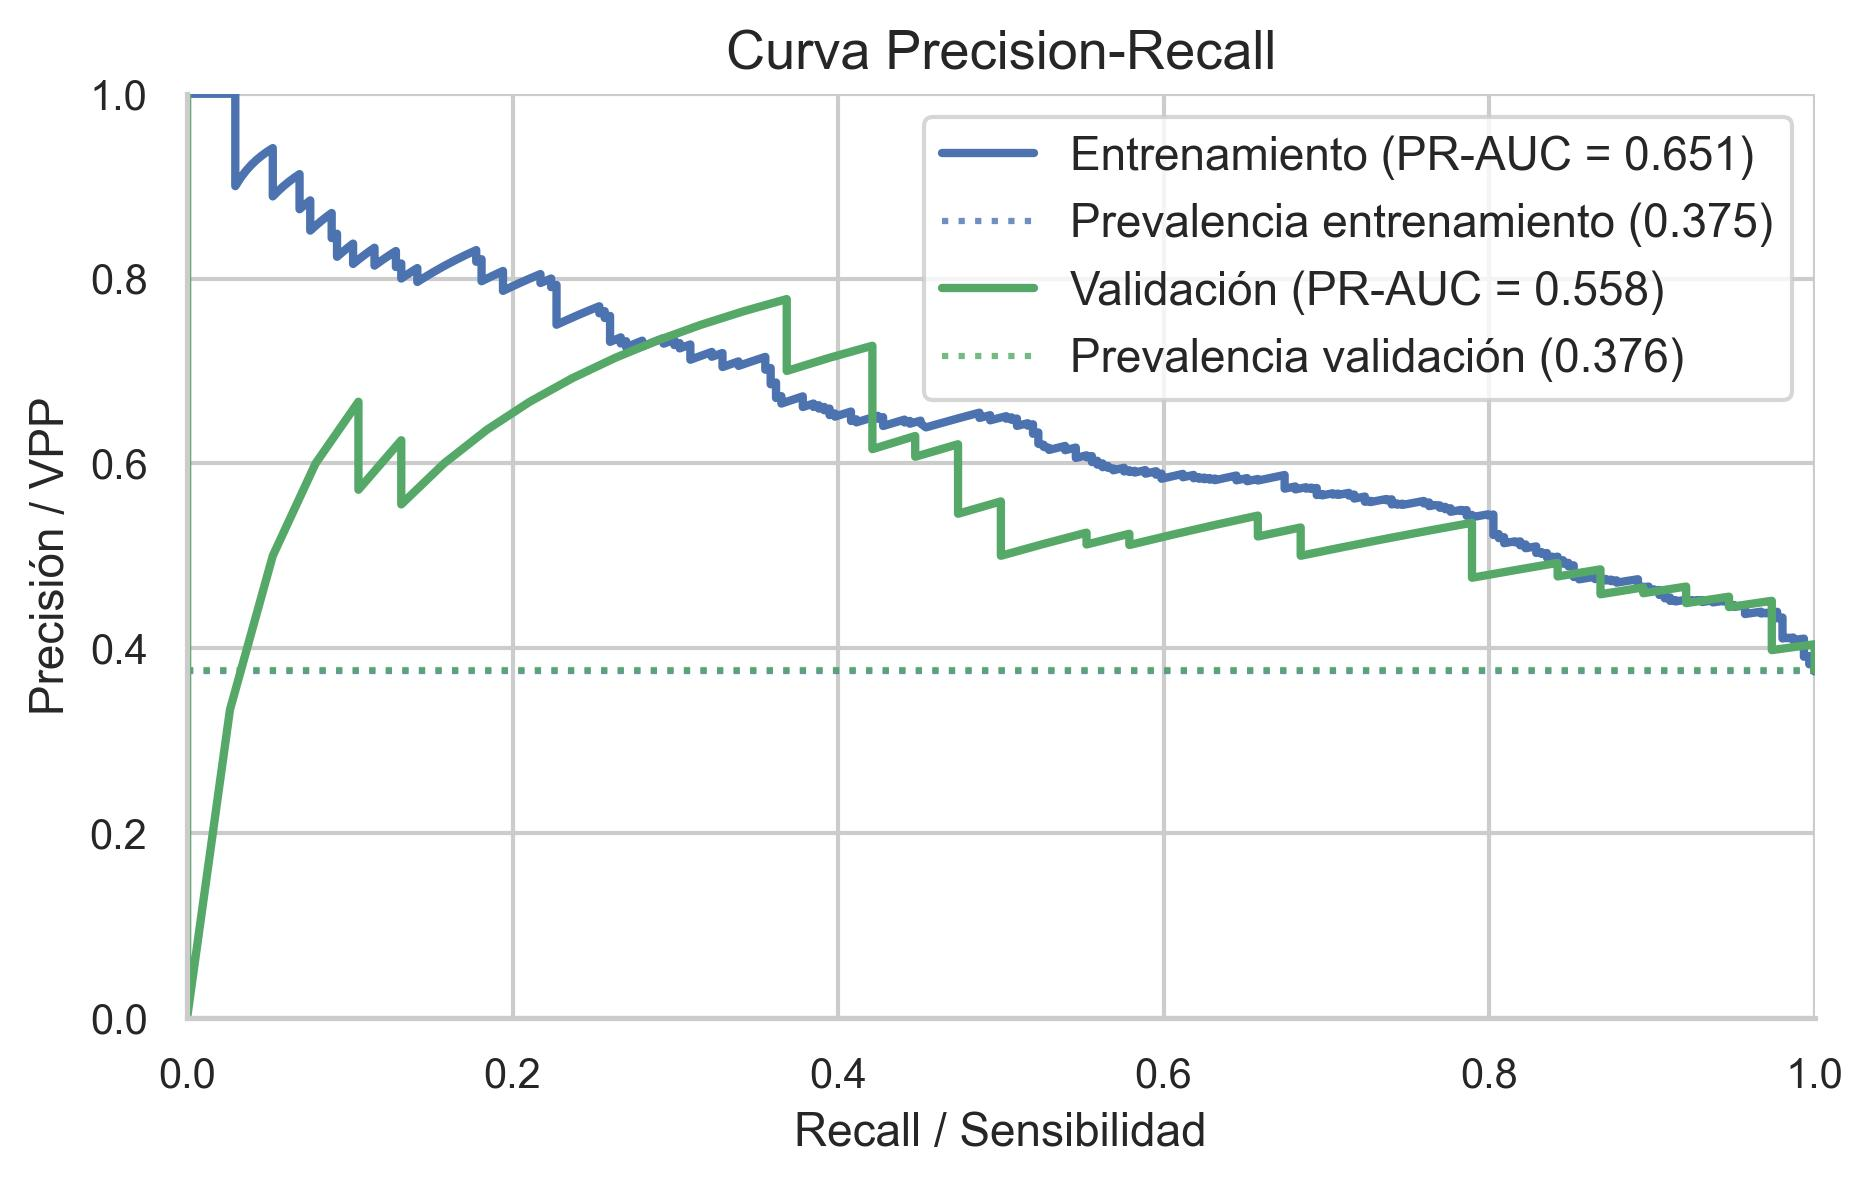

### Roc Curve

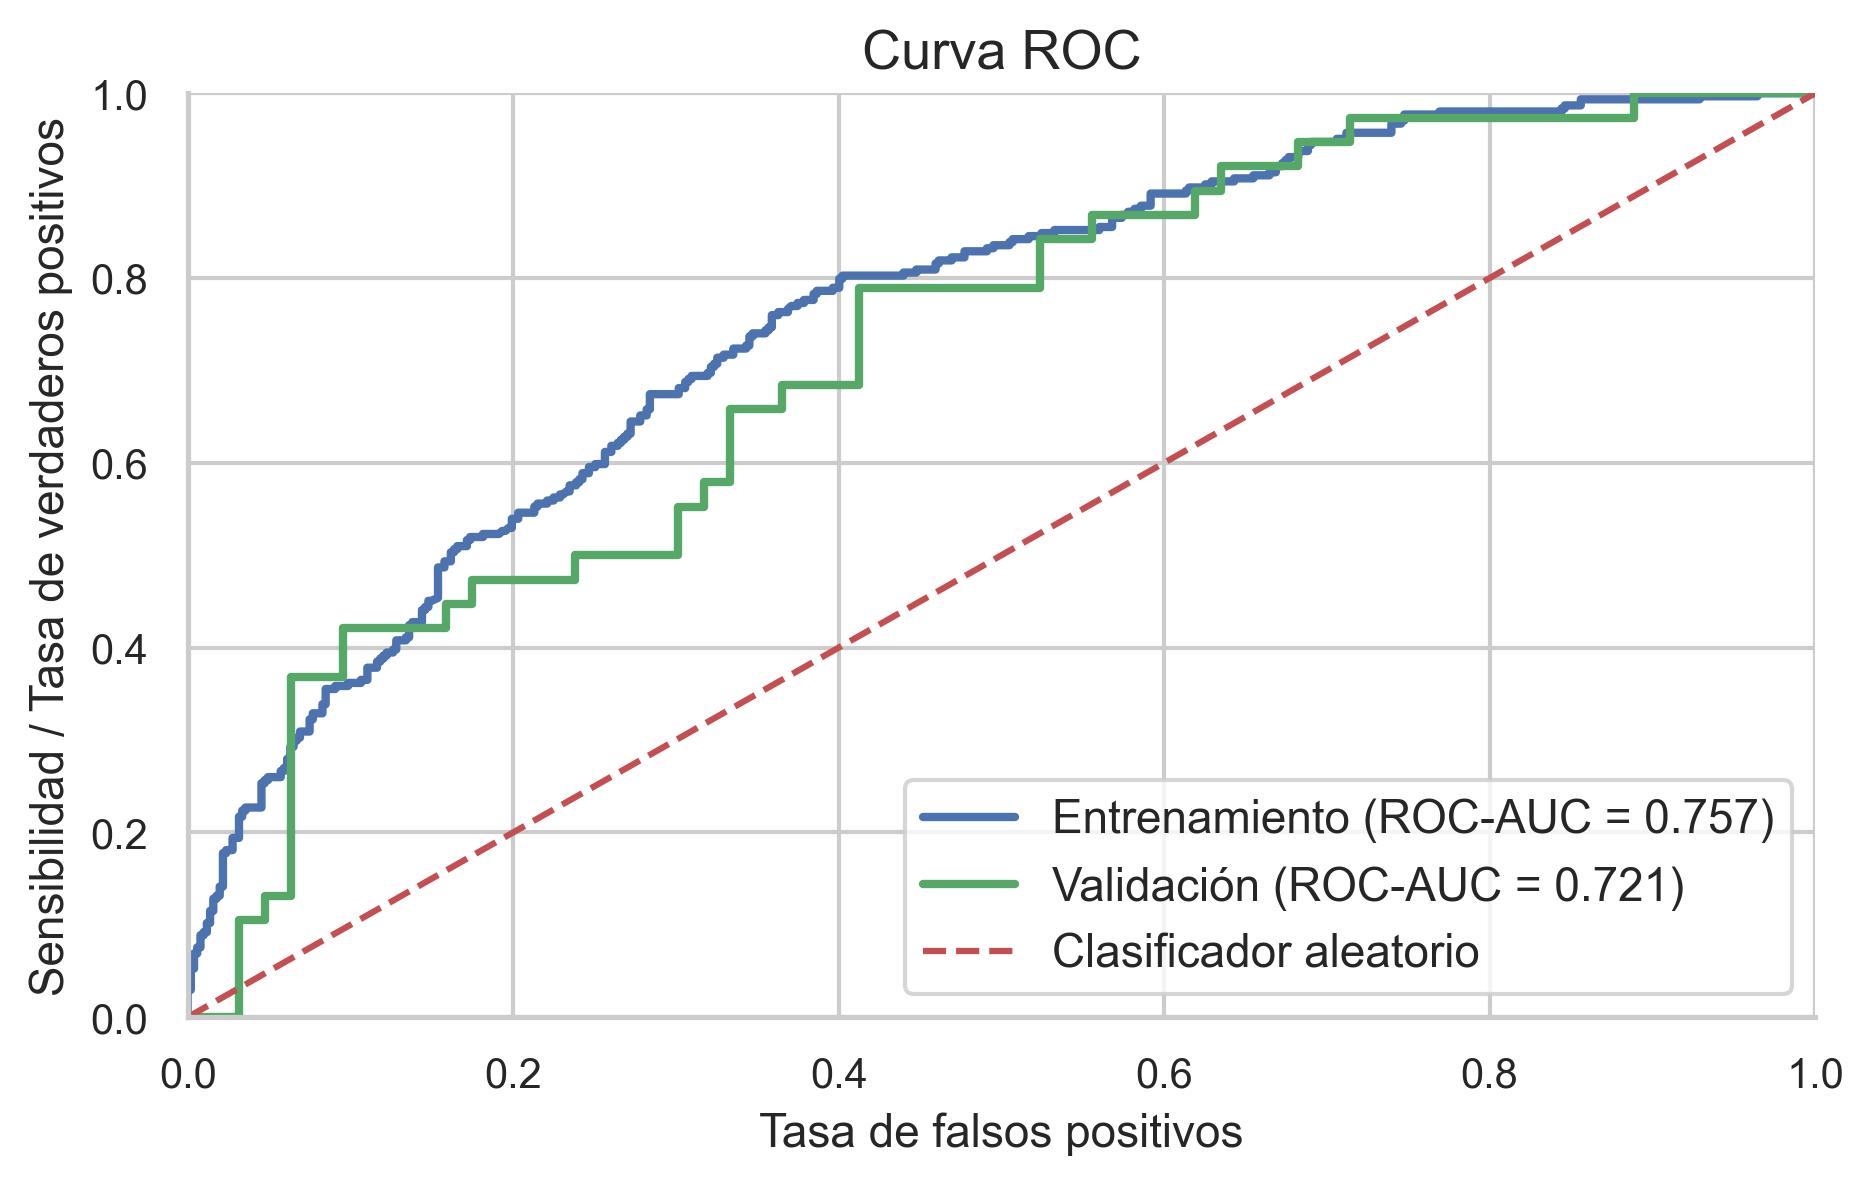

### Pr Roc Curves

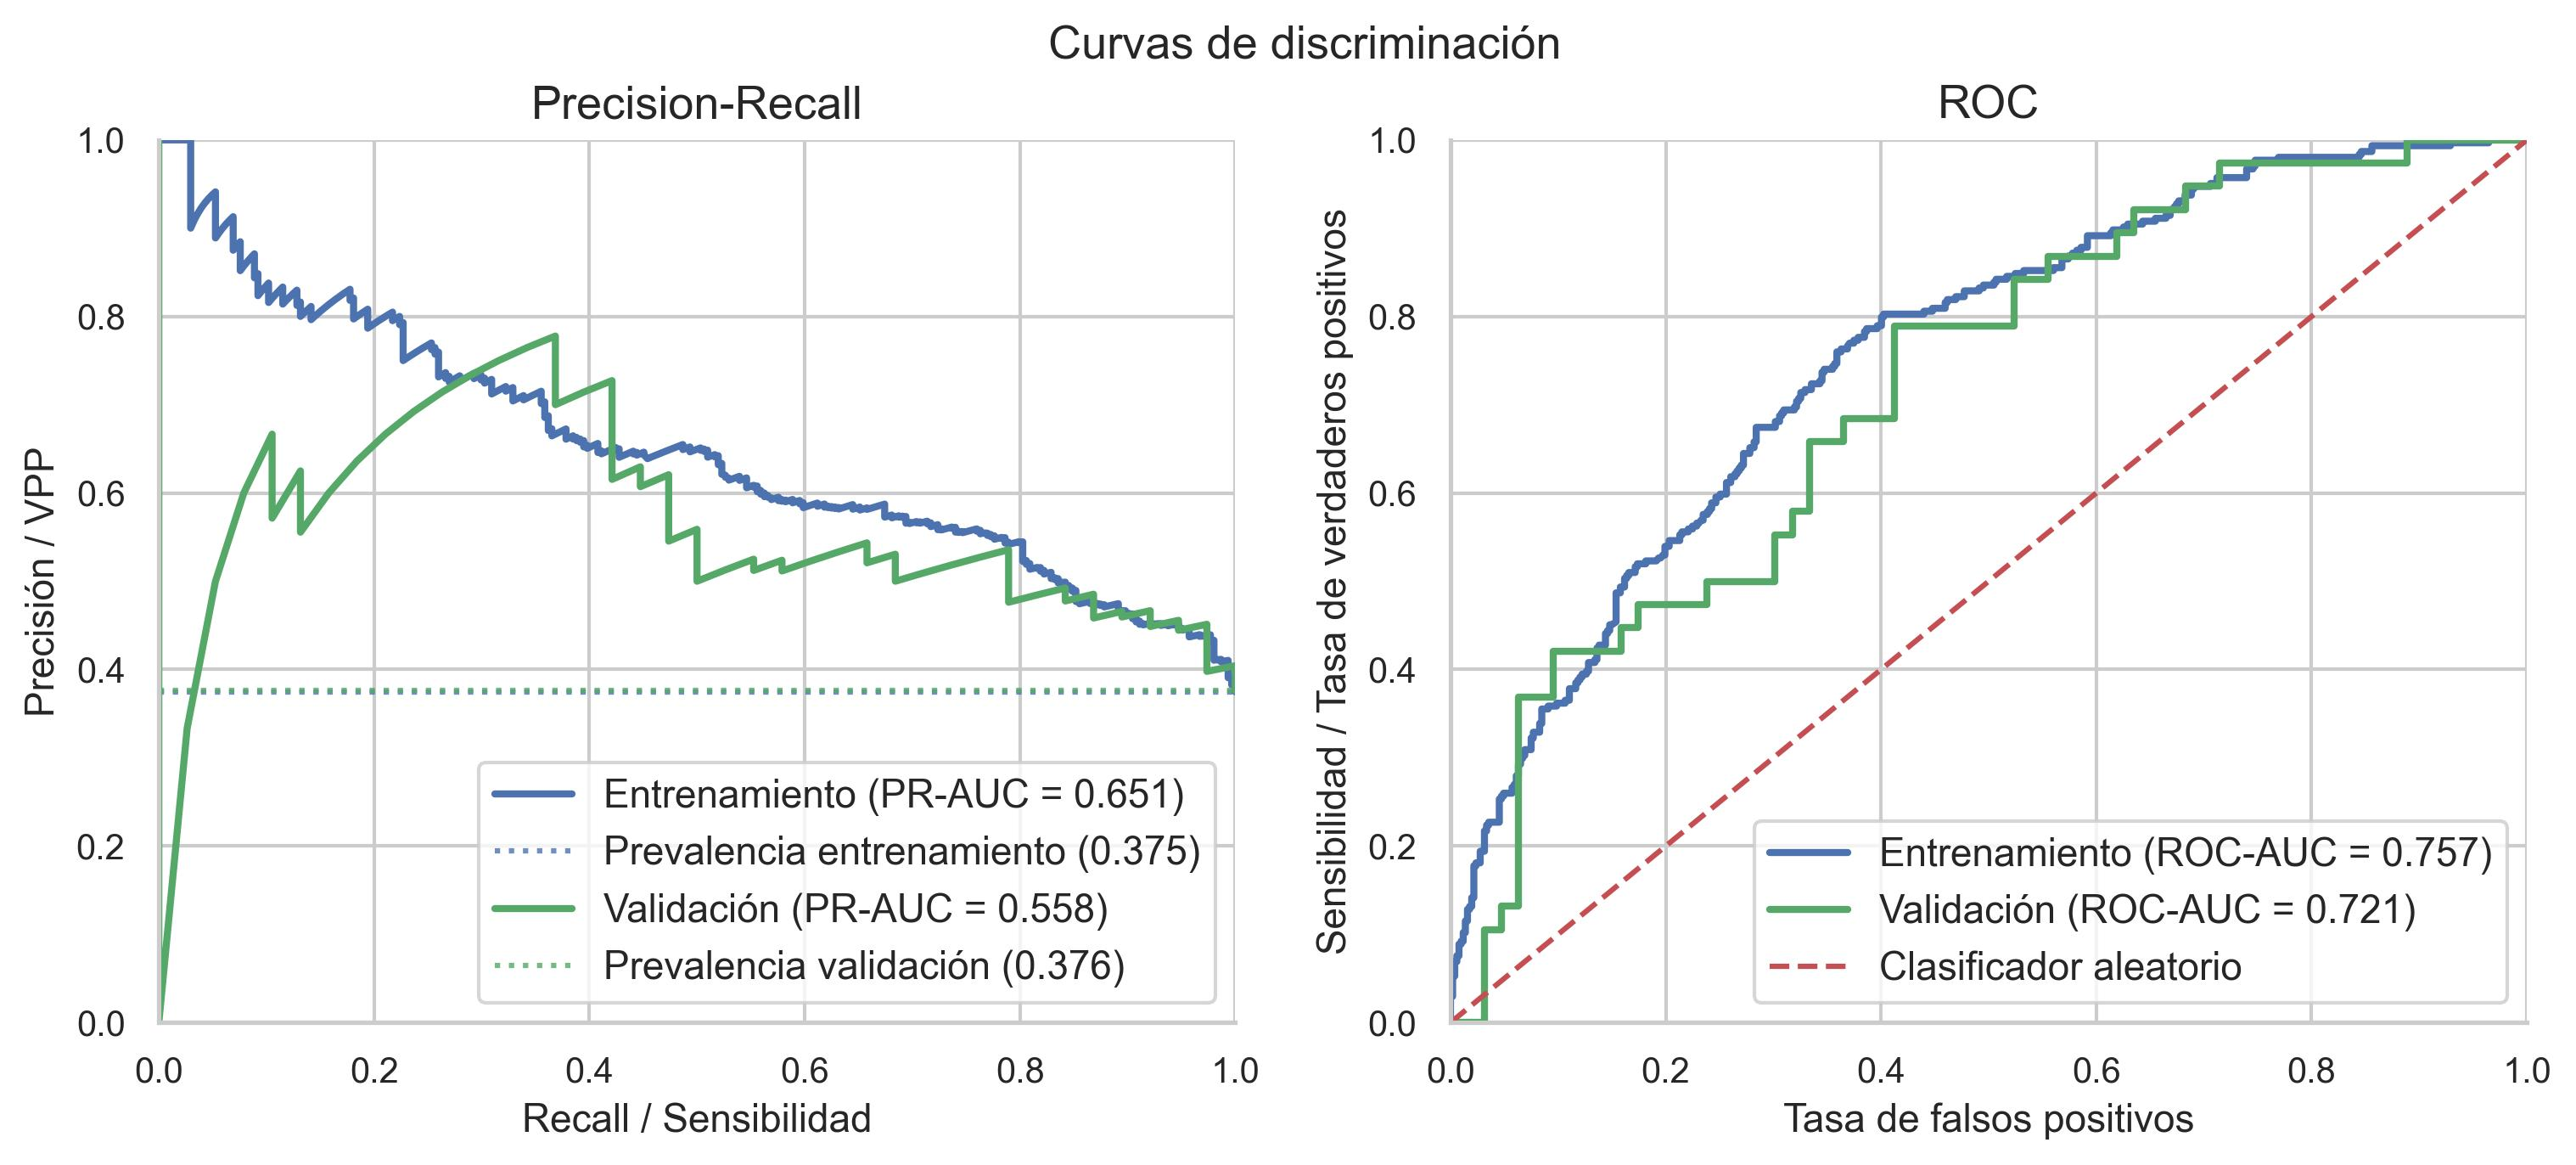

### Clinical Summary

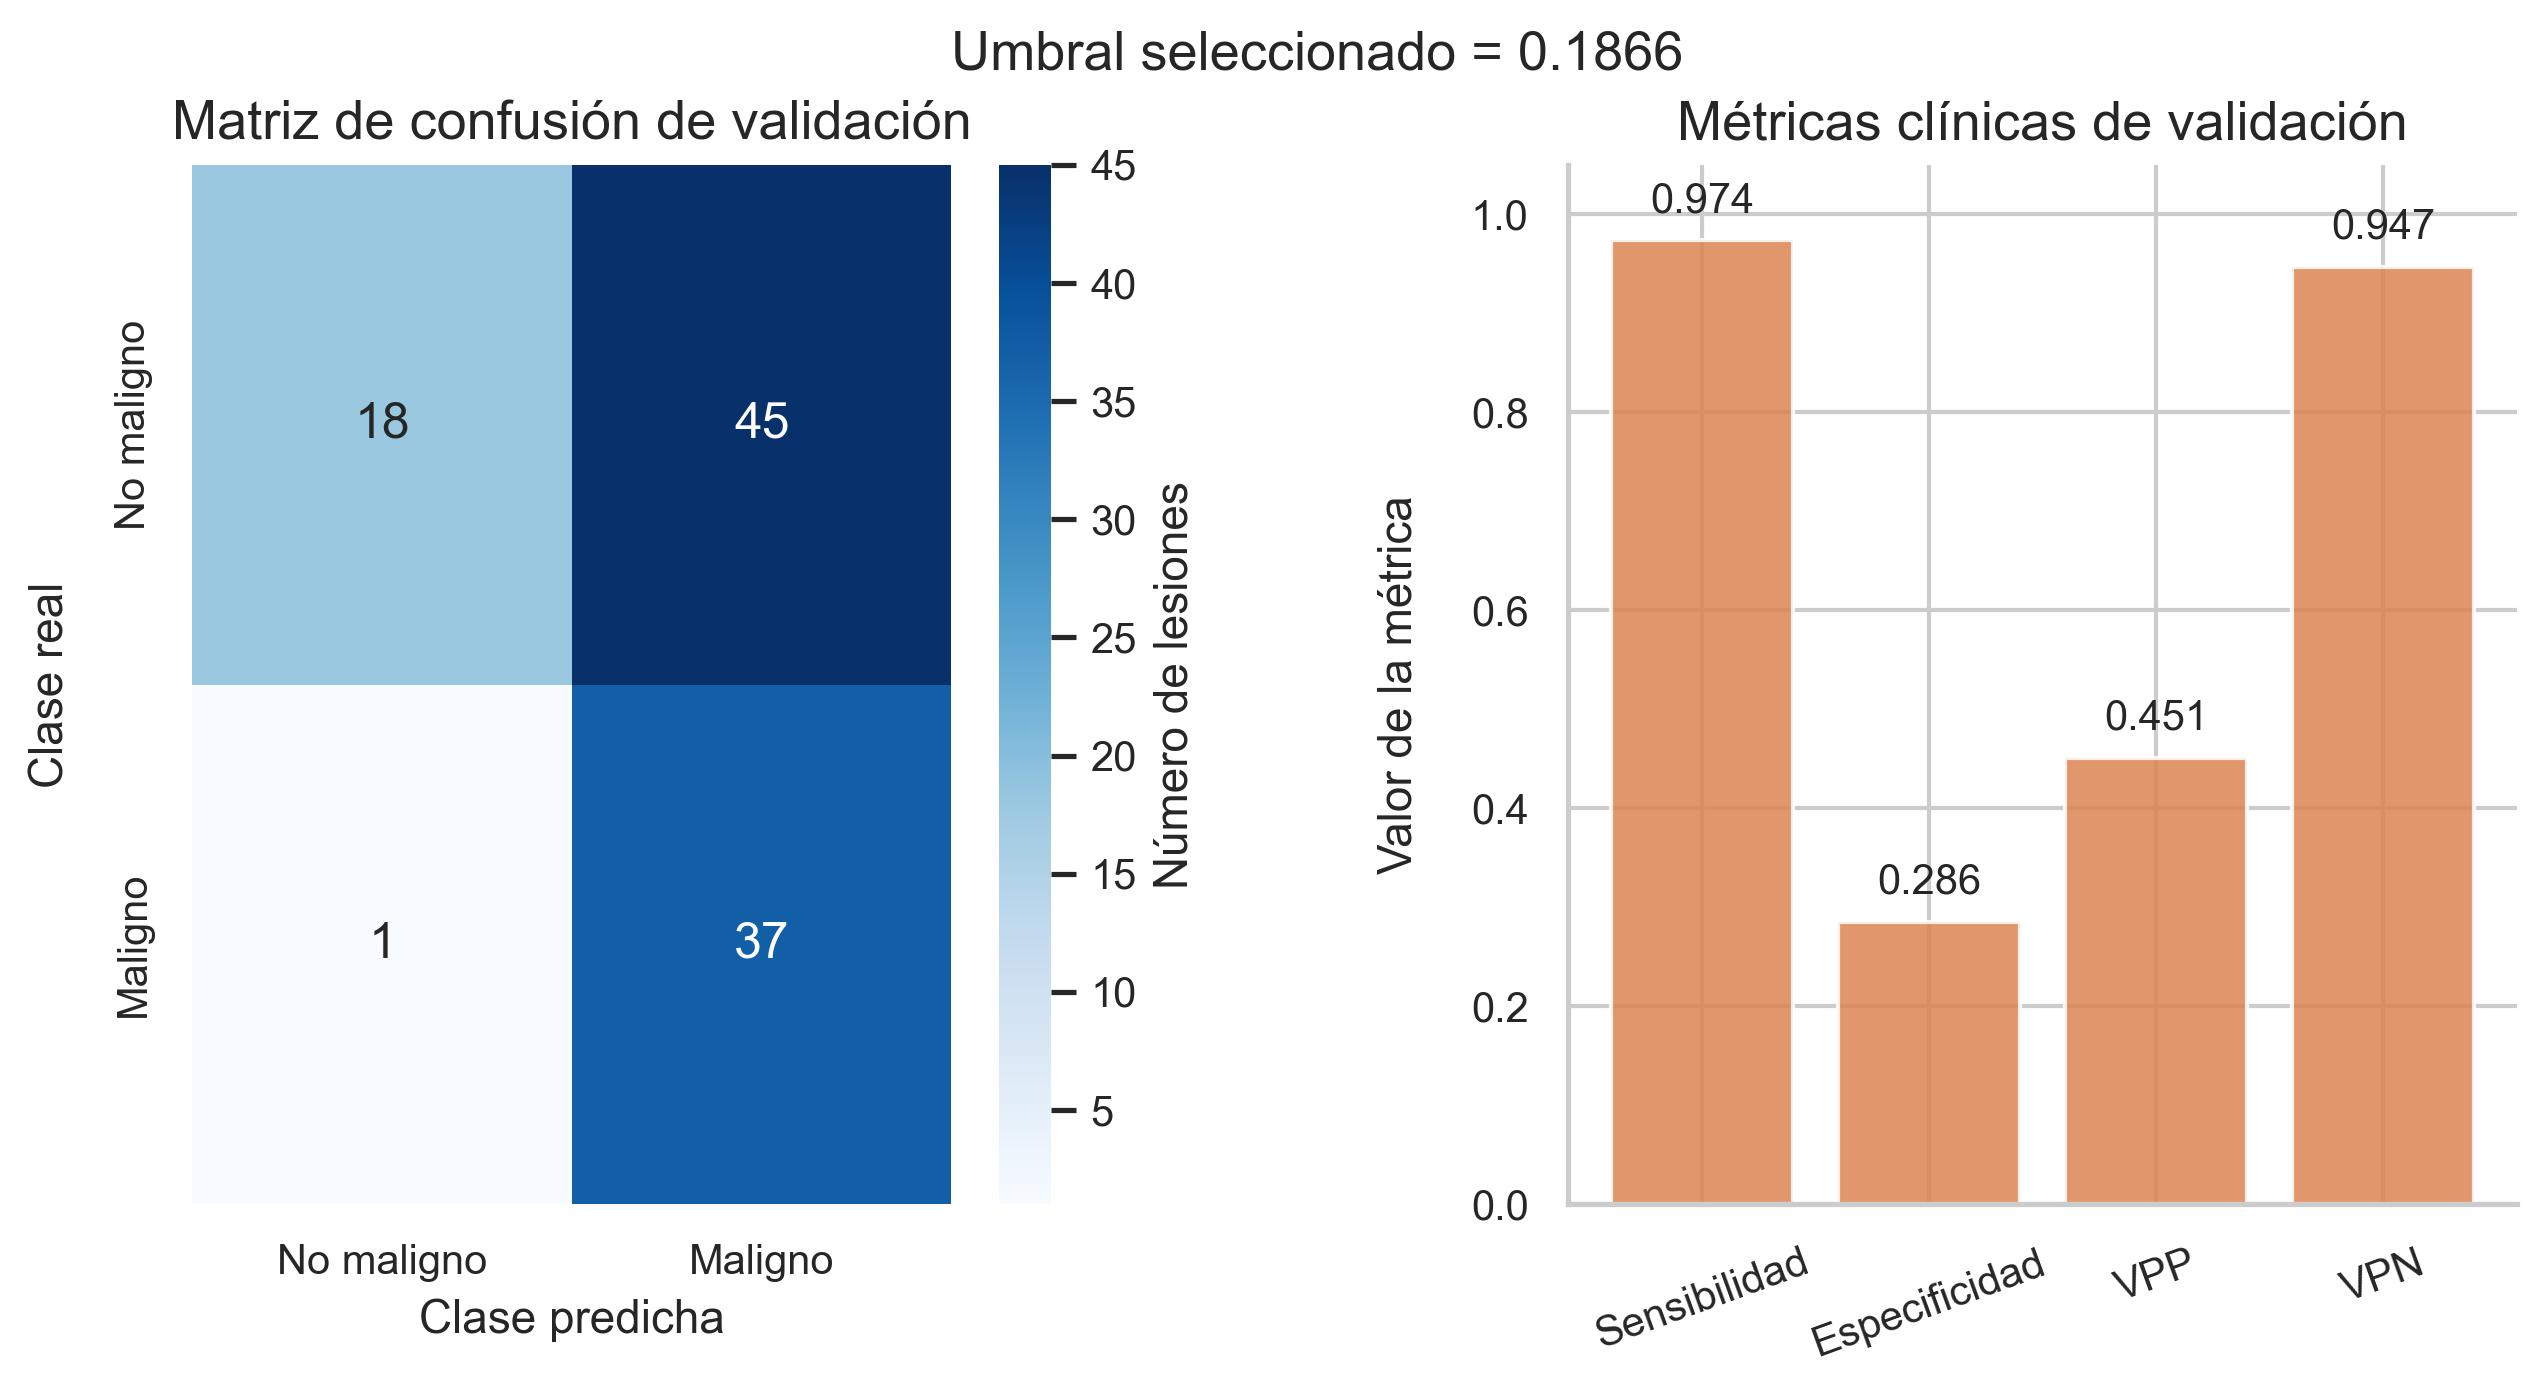

In [31]:
from IPython.display import Image, Markdown, display

for figure_name, figure_path in results["figure_paths"].items():
    display(Markdown(f"### {figure_name.replace('_', ' ').title()}"))
    display(Image(filename=str(figure_path)))